# Demo Notebook -- Full WNN GPU Pipeline

This notebook demonstrates how to use the full WNN pipeline on GPU with a PBMC dummy dataset.

### Load data

This step can be skipped if different data is preferred.

In [8]:
from wnn_pipeline import generate_pbmc_mudata, run_pipeline_on_mudata

# Load PBMC RNA data with dummy ATAC to get example multimodal data
mdata = generate_pbmc_mudata(dummy_atac_features=100)

PBMC MuData: 2700 cells, RNA=32738, ATAC=100


/home/shadeform/miniconda3/envs/rapids-25.08/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/shadeform/miniconda3/envs/rapids-25.08/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


### Run the WNN pipeline

In [9]:
# Run full WNN pipeline
mdata_final, timings = run_pipeline_on_mudata(mdata, k=30, n_components=50)

# Print step timings
for step, t in timings.items():
    print(f"{step}: {t:.2f}s")

Part 1 complete

PART 2 PIPELINE: PCA + kNN ANALYSIS
Input: MuData object with n_obs × n_vars = 2700 × 32838
  uns:	'wnn_params', 'wnn_alignment', 'wnn_runtime'
  2 modalities
    rna:	2700 x 32738
      var:	'gene_ids'
    atac:	2700 x 100
Parameters: n_components=50, k=30

[PHASE 1] GPU Environment Setup
------------------------------
📦 Checking basic packages...
✅ Basic packages available
🔧 Fixing CUDA libraries...
✅ Loaded 0 libraries: 
⚠️ Failed to load 9 libraries: libcudart.so.12 (not found at /home/shadeform/.local/lib/python3.10/site-packages/nvidia/cuda_runtime/lib/libcudart.so.12), libnvrtc.so.12 (not found at /home/shadeform/.local/lib/python3.10/site-packages/nvidia/cuda_nvrtc/lib/libnvrtc.so.12), libnvrtc-builtins.so.12 (not found at /home/shadeform/.local/lib/python3.10/site-packages/nvidia/cuda_nvrtc/lib/libnvrtc-builtins.so.12), libnvjitlink.so.12 (not found at /home/shadeform/.local/lib/python3.10/site-packages/nvidia/nvjitlink/lib/libnvjitlink.so.12), libcublas.so.12

/home/shadeform/miniconda3/envs/rapids-25.08/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/shadeform/miniconda3/envs/rapids-25.08/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


### Retrieving Fused WNN Graph

In [3]:
from wnn_pipeline import get_fused_wnn

# CPU sparse matrix
W_wnn_cpu = get_fused_wnn(mdata_final, as_gpu=False)

# GPU CuPy sparse matrix
W_wnn_gpu = get_fused_wnn(mdata_final, as_gpu=True)

### Plotting WNN with UMAP

A UMAP from the WNN colored by the clustering can be made using the following:

/home/shadeform/miniconda3/envs/rapids-25.08/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/shadeform/miniconda3/envs/rapids-25.08/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


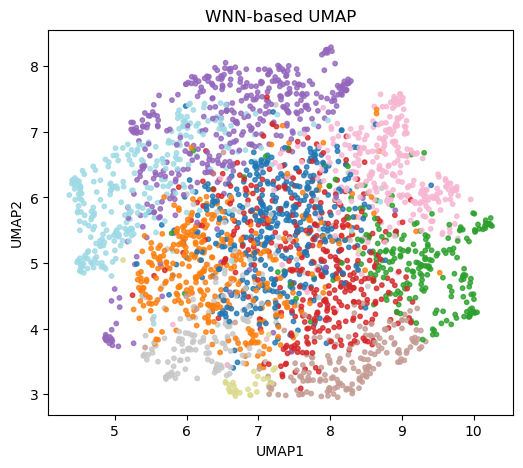

In [4]:
import matplotlib.pyplot as plt
import umap  

# Get fused WNN 
W_wnn_cpu = get_fused_wnn(mdata_final, as_gpu=False) 

# Convert sparse to dense distance
W_dist_cpu = 1 - W_wnn_cpu.toarray()  

# Run UMAP
umap_model = umap.UMAP(n_components=2, metric="precomputed", random_state=42)
X_umap_wnn_cpu = umap_model.fit_transform(W_dist_cpu)

# Cluster labels
clusters = mdata_final.obs['wnn_leiden'].astype(int)

# Plot
plt.figure(figsize=(6,5))
scatter = plt.scatter(
    X_umap_wnn_cpu[:,0], X_umap_wnn_cpu[:,1],
    c=clusters, cmap='tab20', s=10, alpha=0.8
)
plt.title("WNN-based UMAP")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.savefig("wnn_umap_plot.png", dpi=300, bbox_inches="tight")

plt.show()



### Plotting RNA PCA with UMAP

A UMAP from the RNA PCA colored by the clustering can be made using the following:

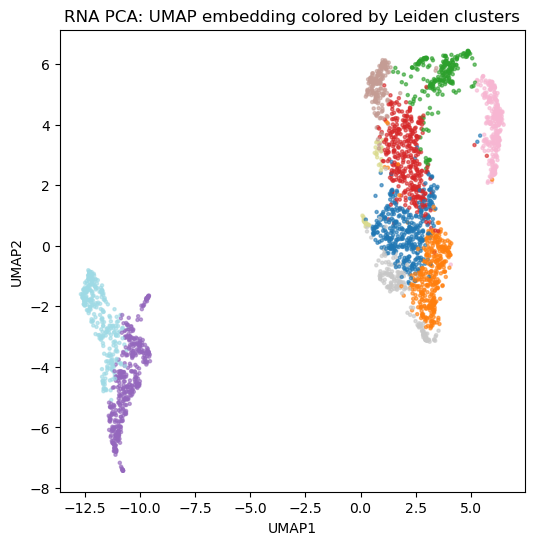

In [7]:
import matplotlib.pyplot as plt
import cupy as cp
import numpy as np

try:
    import cuml
    import cupy as cp
    HAS_CUGRAPH = True
except ImportError:
    HAS_CUGRAPH = False

if HAS_CUGRAPH and 'X_umap_gpu' in mdata_final['rna'].obsm:
    X_umap = cp.asnumpy(mdata_final['rna'].obsm['X_umap_gpu'])
else:
    X_umap = mdata_final['rna'].obsm['X_pca_rna'][:, :2]

X_umap_cpu = cp.asnumpy(X_umap) if hasattr(X_umap, "get") else np.asarray(X_umap)

# Get cluster labels (as integers)
clusters = mdata_final.obs["wnn_leiden"].astype(int).values

plt.figure(figsize=(6,6))
scatter = plt.scatter(
    X_umap_cpu[:,0],
    X_umap_cpu[:,1],
    c=clusters,       # color by cluster
    cmap="tab20",     
    s=5,
    alpha=0.6
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("RNA PCA: UMAP embedding colored by Leiden clusters")
plt.show()
